# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and machine learning. The central thread is this: **can we do better than standard feature selection when we care about robustness under distribution shift?**

We will work through the problem from the ground up — starting with pairwise causal direction tests, moving to full multivariate graph recovery, then to causal feature selection (CFS), and finally comparing CFS-based predictors with standard ones under intervention shifts.

The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

---
**Prerequisites:** basic probability, linear regression, familiarity with Python/sklearn.  
**Packages used:** `numpy`, `sklearn`, `causallearn`, `cdt`, `dcor`, and custom helpers (`generate_scm`, `MB`, `causal_discovery`, `causal_feature_selection`).


In [1]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy / stats
from scipy.stats import pearsonr
from numpy.linalg import lstsq
import dcor

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Data utilities
from cdt.data import load_dataset

# Custom modules / Causal discovery
from src.causal_discovery import ges, adjacency, pc_alg, fci_alg, lingam
from src.causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)
from src.generate_scm import *
from invariant_causal_prediction import icp
from src.kci import kci_test

# Local project modules
# Note: Replaced * with specific imports or module reference for clarity
from src import generate_scm
from src import MB

# Reproducibility
np.random.seed(2)

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Section 3 — Multivariate Causal Feature Selection

### 3.1 The Markov Blanket

Given a target variable Y, the **Markov Blanket (MB)** of Y is the minimal set of variables MB(Y) such that Y is conditionally independent of all other variables given MB(Y):

$$Y \perp \mathbf{X}_{\text{rest}} \mid MB(Y)$$

In a DAG, MB(Y) = parents(Y) ∪ children(Y) ∪ spouses(Y), where spouses are the other parents of Y's children.

The MB has a key property for feature selection: it is the minimal sufficient set for predicting Y. No variable outside the MB adds any predictive information once we condition on MB(Y).

### 3.2 Why not just use the full graph?

Running a full causal discovery algorithm (PC, GES) and then extracting the MB is one option. But:
- It requires recovering the full graph, which is expensive
- Errors in distant parts of the graph can propagate to MB estimation
- MB-specific algorithms are more efficient

### 3.3 MB algorithms

**HITON-MB**: Constraint-based. Builds the MB incrementally using a HITON-PC phase (find parents/children) followed by a spouse discovery phase.

**IAMB**: Incremental Association MB. Two phases: grow (add variables that are associated with Y given current MB) and shrink (remove variables that are conditionally independent of Y given the rest of the MB).

**MB-GES**: Score-based. Uses GES restricted to the neighborhood of Y.

**RESIT-MB**: Functional. Extends the pairwise RESIT idea to identify the MB via regression and independence testing.


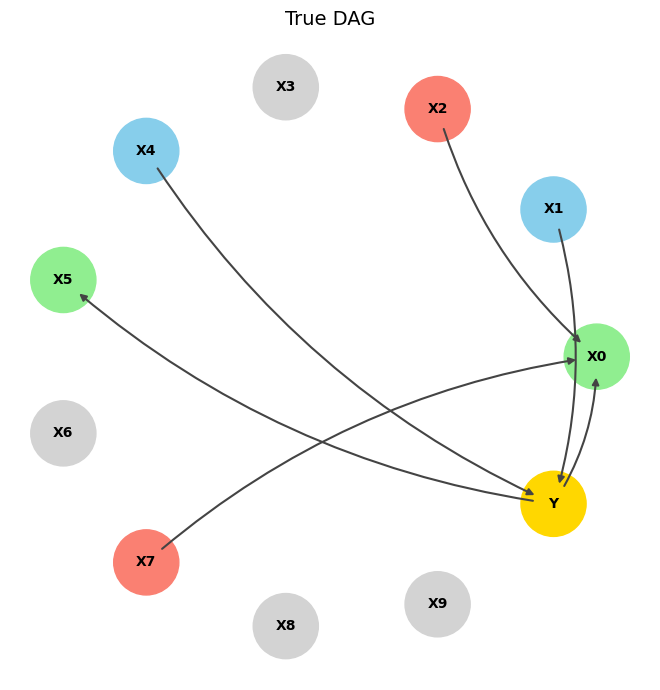

True parents of Y:  [np.int64(1), np.int64(4)]
True children of Y: [np.int64(0), np.int64(5)]
True spouses of Y:  [np.int64(2), np.int64(7)]
True MB of Y:       [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]


In [2]:
# Generate a slightly denser SCM
d = 10
scm = SCMGenerator(d=d)
scm.fit(n_parents=2, n_childs=2, n_spouses=2, sparsity=0.1, noise_type='gaussian', is_linear=True)
col_names = np.hstack((np.array([f'X{i}' for i in range(scm.n_nodes-1)]), np.array(['Y'])))
plot_graphs_from_adj([scm.A], [d], [col_names], ['True DAG'])

print(f"True parents of Y:  {sorted(scm.parents_idx)}")
print(f"True children of Y: {sorted(scm.children_idx)}")
print(f"True spouses of Y:  {sorted(scm.spouses_idx)}")
true_mb = set(scm.parents_idx) | set(scm.children_idx) | set(scm.spouses_idx)
print(f"True MB of Y:       {sorted(true_mb)}")


In [3]:
# Sample data
data = scm.sample(n_samples=20000)
data.head()


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,-1.577161,-0.275572,0.017297,1.174161,0.665390,1.136332,-1.392594,-2.462041,-0.142829,-0.289812,-1.221182
1,-0.497584,1.463718,1.536457,-0.956860,-0.848629,-3.410231,-0.087950,0.472424,-0.313384,0.965461,3.130041
2,-3.392120,0.651552,-0.116539,-0.696839,-0.155642,0.169519,0.292442,-1.876322,-0.766184,-0.515344,0.834412
3,-1.878691,1.506694,0.374157,2.121058,-0.941800,-2.648865,0.565268,-0.489568,-1.255587,-0.202047,2.534328
4,1.606789,-0.210769,-0.320921,-1.533335,0.387201,0.604696,-0.689437,0.927197,0.088254,-0.438586,-0.841567


### 3.4 Run four MB algorithms and compare


In [4]:
# HITON-MB
start = time.time()
mb_hiton = hiton_mb(data, 'Y', alpha=0.05, ci_method='partial')
hiton_time = time.time() - start
print(f"HITON-MB  : {hiton_time:.2f}s  ->  {sorted(mb_hiton)}")

# IAMB
start = time.time()
mb_iamb = iamb(data, 'Y', alpha=0.05, ci_method='partial')
iamb_time = time.time() - start
print(f"IAMB      : {iamb_time:.2f}s  ->  {sorted(mb_iamb)}")

# MB-GES
start = time.time()
mb_ges_result = mb_ges(data, 'Y')
ges_time = time.time() - start
print(f"MB-GES    : {ges_time:.2f}s  ->  {sorted(mb_ges_result)}")

# RESIT-MB
start = time.time()
mb_resit = resit_mb(data, 'Y', alpha=0.05)
resit_time = time.time() - start
print(f"RESIT-MB  : {resit_time:.2f}s  ->  {sorted(mb_resit)}")

print(f"\nTrue MB   :         ->  {sorted(true_mb)}")


HITON-MB  : 1.01s  ->  ['X0', 'X1', 'X2', 'X4', 'X5', 'X7']
IAMB      : 0.77s  ->  ['X0', 'X1', 'X2', 'X4', 'X5', 'X7', 'X8']
MB-GES    : 0.47s  ->  ['X0', 'X1', 'X2', 'X4', 'X5', 'X7']
RESIT-MB  : 1.27s  ->  ['X3', 'X6', 'X7', 'X8', 'X9']

True MB   :         ->  [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]


In [5]:
# Jaccard similarity: how close is each MB estimate to the truth?
def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

results = {
    'HITON-MB': mb_hiton,
    'IAMB':     mb_iamb,
    'MB-GES':   mb_ges_result,
    'RESIT-MB': mb_resit,
}

print("Algorithm  | Jaccard vs True MB | Extra vars | Missing vars")
print("-" * 65)
for name, mb in results.items():
    mb_set = set(mb)
    j = jaccard(mb_set, true_mb)
    extra = mb_set - true_mb
    missing = true_mb - mb_set
    print(f"{name:<10} | {j:.3f}              | {sorted(extra)} | {sorted(missing)}")


Algorithm  | Jaccard vs True MB | Extra vars | Missing vars
-----------------------------------------------------------------
HITON-MB   | 0.000              | ['X0', 'X1', 'X2', 'X4', 'X5', 'X7'] | [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]
IAMB       | 0.000              | ['X0', 'X1', 'X2', 'X4', 'X5', 'X7', 'X8'] | [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]
MB-GES     | 0.000              | ['X0', 'X1', 'X2', 'X4', 'X5', 'X7'] | [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]
RESIT-MB   | 0.000              | ['X3', 'X6', 'X7', 'X8', 'X9'] | [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]


### Questions — Markov Blanket algorithms

**Q11.** IAMB has a grow phase and a shrink phase. Could you skip the shrink phase? What would go wrong?

**Q12.** All four algorithms use a significance level α for independence tests. What is the effect of a very strict α (e.g., 1e-5) on the estimated MB in terms of false positives and false negatives?

**Q13.** HITON-MB and IAMB both find the MB, but their running time differs. What determines their complexity, and in what regime would one be faster than the other?

**Q14.** RESIT-MB works differently from HITON and IAMB — it doesn't use conditional independence tests in the same way. Can you think of a case where RESIT-MB would succeed while HITON/IAMB would fail?


**Answers:**

**A11.** Skipping the shrink phase would leave false positives in the MB — variables that were added during the grow phase because they appeared associated with Y given an incomplete conditioning set, but become independent once the full MB is in the conditioning set. The grow phase is a necessary but not sufficient filter. The shrink phase is what removes "false alarms" caused by the initially incomplete context.

**A12.** Very strict α (e.g., 1e-5): The test rarely rejects the null of independence, so variables stay in the MB even if they are conditionally independent of Y. This leads to a bloated MB with many false positives (non-MB variables included). The estimated MB has high recall but low precision. With α = 0.5: the test rejects too easily, removing true MB members. High precision but low recall.

**A13.** HITON-MB first finds PC(Y) (parents/children) in one pass, then adds spouses. IAMB does a joint grow/shrink over the entire MB simultaneously. IAMB tends to be slower per variable because the conditioning set grows larger during the shrink phase, making each CI test more expensive. HITON can be faster when the graph is sparse because PC(Y) is small. In dense graphs or when the MB is large, IAMB may be more efficient because it avoids redundant spouse searches.

**A14.** RESIT-MB is a functional method — it exploits the residual independence property of SCMs. If the relationship between Y and its causes is nonlinear but additive noise (Y = f(parents) + ε), and the noise distribution is non-Gaussian, RESIT-MB can identify the MB even when the nonlinearity makes partial correlation-based CI tests unreliable. HITON and IAMB with partial correlation CI tests assume linear Gaussian relationships (or require kernel-based CI tests for the nonlinear case, which are expensive).


### Exercise 3 — Effect of sample size on MB recovery

Repeat the MB estimation with `n_samples = 500` and `n_samples = 2000`. Report Jaccard similarity for each algorithm and sample size. Which algorithm degrades most gracefully?


In [6]:
# Your code here
# for n in [500, 2000, 20000]:
#     data_n = scm.sample(n_samples=n)
#     ...
